In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString
import contextily as ctx
from matplotlib.lines import Line2D

In [7]:
def _get_node_latlon(nodedata):
    if not isinstance(nodedata, dict):
        return None
    if "lat" in nodedata and "lon" in nodedata:
        return float(nodedata["lat"]), float(nodedata["lon"])
    if "y" in nodedata and "x" in nodedata:
        return float(nodedata["y"]), float(nodedata["x"])
    if "latitude" in nodedata and "longitude" in nodedata:
        return float(nodedata["latitude"]), float(nodedata["longitude"])
    return None

def graph_to_gdf_edges(G, prefer_nodes=False):
    records = []
    if hasattr(G, "edges"):
        iterator = G.edges(data=True, keys=True) if getattr(G, "is_multigraph", lambda: False)() else G.edges(data=True)
    else:
        iterator = []
        for u, nbrs in G.items():
            for v, data in nbrs.items():
                iterator.append((u, v, data))

    for item in iterator:
        if len(item) == 4:
            u, v, _k, data = item
        else:
            u, v, data = item
        if not isinstance(data, dict):
            continue

        line = None
        geom = data.get("geometry", None)

        if (not prefer_nodes) and (geom is not None) and getattr(geom, "geom_type", None) == "LineString":
            line = geom
        else:
            nu = G.nodes[u] if hasattr(G, "nodes") else G.get(u, {})
            nv = G.nodes[v] if hasattr(G, "nodes") else G.get(v, {})
            pu = _get_node_latlon(nu)
            pv = _get_node_latlon(nv)
            if pu is None or pv is None:
                if (geom is not None) and getattr(geom, "geom_type", None) == "LineString":
                    line = geom
                else:
                    continue
            else:
                line = LineString([(pu[1], pu[0]), (pv[1], pv[0])])

        records.append({"geometry": line})

    if not records:
        raise RuntimeError("Non sono riuscito a costruire geometrie di archi.")

    gdf = gpd.GeoDataFrame(records, geometry="geometry", crs="EPSG:4326")
    return gdf

def _format_lonlat_axes_3857(ax):
    try:
        from pyproj import Transformer
        tr = Transformer.from_crs(3857, 4326, always_xy=True)
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        cx = 0.5*(xlim[0]+xlim[1]); cy = 0.5*(ylim[0]+ylim[1])

        xt = ax.get_xticks(); yt = ax.get_yticks()
        xtlabels = [f"{tr.transform(x, cy)[0]:.3f}" for x in xt]
        ytlabels = [f"{tr.transform(cx, y)[1]:.3f}" for y in yt]
        ax.set_xticklabels(xtlabels, rotation=45)
        ax.set_yticklabels(ytlabels)
        # ax.set_xlabel("Longitude")
        # ax.set_ylabel("Latitude")
    except Exception:
        pass

def make_overlay_pdf(orig_pkl, trans_pkl, out_pdf,
                     pad_frac=0.03,
                     basemap="CartoDB.PositronNoLabels",
                     zoom=None,
                     trans_from_nodes=True,
                     figsize=(10, 10)):
    with open(orig_pkl, "rb") as f:
        G_orig = pickle.load(f)
    with open(trans_pkl, "rb") as f:
        G_trans = pickle.load(f)

    gdf_o_wgs = graph_to_gdf_edges(G_orig,  prefer_nodes=False)
    gdf_t_wgs = graph_to_gdf_edges(G_trans, prefer_nodes=trans_from_nodes)

    gdf_o = gdf_o_wgs.to_crs(3857)
    gdf_t = gdf_t_wgs.to_crs(3857)

    bounds = np.array([gdf_o.total_bounds, gdf_t.total_bounds])
    minx, miny = bounds[:, 0].min(), bounds[:, 1].min()
    maxx, maxy = bounds[:, 2].max(), bounds[:, 3].max()
    pad_x = (maxx - minx) * pad_frac
    pad_y = (maxy - miny) * pad_frac
    
    # Normalizza l'aspect ratio per rispettare figsize
    content_width = (maxx - minx) + 2 * pad_x
    content_height = (maxy - miny) + 2 * pad_y
    target_aspect = figsize[0] / figsize[1]  # larghezza / altezza
    current_aspect = content_width / content_height
    
    # Espandi l'asse più piccolo per far corrispondere l'aspect ratio target
    if current_aspect < target_aspect:
        # L'area è troppo alta, espandi la larghezza
        target_width = content_height * target_aspect
        extra_width = (target_width - content_width) / 2
        pad_x += extra_width
    else:
        # L'area è troppo larga, espandi l'altezza
        target_height = content_width / target_aspect
        extra_height = (target_height - content_height) / 2
        pad_y += extra_height

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")

    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_aspect("equal")

    try:
        provider = ctx.providers
        for part in basemap.split("."):
            provider = getattr(provider, part)
        kwargs = dict(ax=ax, crs=gdf_o.crs, source=provider, alpha=1.0, attribution=False, zorder=0)
        if isinstance(zoom, int):
            kwargs["zoom"] = zoom
        ctx.add_basemap(**kwargs)
    except Exception as e:
        print(f"[info] Basemap saltato: {e}")

    original_color = "#ef8a62"
    tranlated_color = "#67a9cf"

    gdf_o.plot(ax=ax, color=original_color, linewidth=0.7, alpha=0.95, zorder=2, rasterized=True)
    gdf_t.plot(ax=ax, color=tranlated_color, linewidth=0.9, alpha=0.45, zorder=3, rasterized=True)

    _format_lonlat_axes_3857(ax)

    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

    legend_elems = [
        Line2D([0], [0], color=original_color, lw=2.2, label="Original network"),
        Line2D([0], [0], color=tranlated_color, lw=2.2, label="Transformed network"),
    ]
    ax.legend(handles=legend_elems, frameon=True, loc="lower right")

    # Layout per assicurare che tutto sia visibile
    fig.tight_layout()

    os.makedirs(os.path.dirname(out_pdf), exist_ok=True)
    fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.1)
    print(f"[ok] Saved overlay to: {out_pdf}")
    
    plt.show()
    plt.close(fig)



In [8]:
city = "atlanta"  # Options: "barcelone", "santiago" or "atlanta"

base_path = "/home/fbellisardi/code/topolity/data/data_processed"

if city == "barcelone":
    orig_pkl = f"{base_path}/barcelone/graphs/graph_original.pkl"
    trans_pkl = f"{base_path}/barcelone/graphs/graph_translated_10.pkl"
    out_pdf = f"/home/fbellisardi/code/topolity/paper/images/fig3/translation_barcelona.pdf"
elif city == "santiago":
    orig_pkl = f"{base_path}/santiago/graphs/graph_original.pkl"
    trans_pkl = f"{base_path}/santiago/graphs/graph_rot_45.pkl"
    out_pdf = f"/home/fbellisardi/code/topolity/paper/images/fig3/rotation_santiago.pdf"
elif city == "atlanta":
    orig_pkl = f"{base_path}/atlanta/graphs/graph_original.pkl"
    # Directional scaling options: 'ew' (east-west), 'ns' (north-south), 'both'
    scale_dir = 'ew'  # change to 'ns' or 'both' as needed
    scale_factor = 1.5  # multiplicative factor (e.g., 1.5 -> 150%)
    tx_tag = f"scale_{int(scale_factor*100)}_{scale_dir}"
    trans_pkl = f"{base_path}/atlanta/graphs/graph_{tx_tag}.pkl"
    out_pdf = f"/home/fbellisardi/code/topolity/paper/images/fig3/{tx_tag}_atlanta.pdf"
    # create scaled PKL if missing
    import os, pickle, copy, numpy as _np
    def _scale_graph_nodes_directional(G, scale_x=1.0, scale_y=1.0):
        H = copy.deepcopy(G)
        coords = []
        # Collect node coords (lon, lat or x,y) to compute centroid
        for _n, data in H.nodes(data=True):
            if not isinstance(data, dict):
                continue
            if 'x' in data and 'y' in data:
                coords.append((float(data['x']), float(data['y'])))
            elif 'lon' in data and 'lat' in data:
                coords.append((float(data['lon']), float(data['lat'])))
            elif 'longitude' in data and 'latitude' in data:
                coords.append((float(data['longitude']), float(data['latitude'])))
        if not coords:
            return H
        arr = _np.array(coords)
        cx, cy = arr.mean(axis=0)
        for _n, data in H.nodes(data=True):
            if not isinstance(data, dict):
                continue
            if 'x' in data and 'y' in data:
                x, y = float(data['x']), float(data['y'])
                data['x'] = cx + scale_x * (x - cx)
                data['y'] = cy + scale_y * (y - cy)
            elif 'lon' in data and 'lat' in data:
                lon, lat = float(data['lon']), float(data['lat'])
                data['lon'] = cx + scale_x * (lon - cx)
                data['lat'] = cy + scale_y * (lat - cy)
            elif 'longitude' in data and 'latitude' in data:
                lon, lat = float(data['longitude']), float(data['latitude'])
                data['longitude'] = cx + scale_x * (lon - cx)
                data['latitude'] = cy + scale_y * (lat - cy)
        return H
    # determine directional factors
    if scale_dir == 'ew':
        sx, sy = scale_factor, 1.0
    elif scale_dir == 'ns':
        sx, sy = 1.0, scale_factor
    else:
        sx, sy = scale_factor, scale_factor
    if not os.path.exists(trans_pkl):
        with open(orig_pkl, 'rb') as _f: G_orig = pickle.load(_f)
        G_scaled = _scale_graph_nodes_directional(G_orig, scale_x=sx, scale_y=sy)
        os.makedirs(os.path.dirname(trans_pkl), exist_ok=True)
        with open(trans_pkl, 'wb') as _f: pickle.dump(G_scaled, _f)
else:
    pass

print(f"City: {city}")
print(f"Original graph: {orig_pkl}")
print(f"Transformed graph: {trans_pkl}")
print(f"Output PDF: {out_pdf}")


City: atlanta
Original graph: /home/fbellisardi/code/topolity/data/data_processed/atlanta/graphs/graph_original.pkl
Transformed graph: /home/fbellisardi/code/topolity/data/data_processed/atlanta/graphs/graph_scale_150_ew.pkl
Output PDF: /home/fbellisardi/code/topolity/paper/images/fig3/scale_150_ew_atlanta.pdf


/tmp/ipykernel_762740/791003904.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtlabels, rotation=45)
/tmp/ipykernel_762740/791003904.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ytlabels)


[ok] Saved overlay to: /home/fbellisardi/code/topolity/paper/images/fig3/scale_150_ew_atlanta.pdf


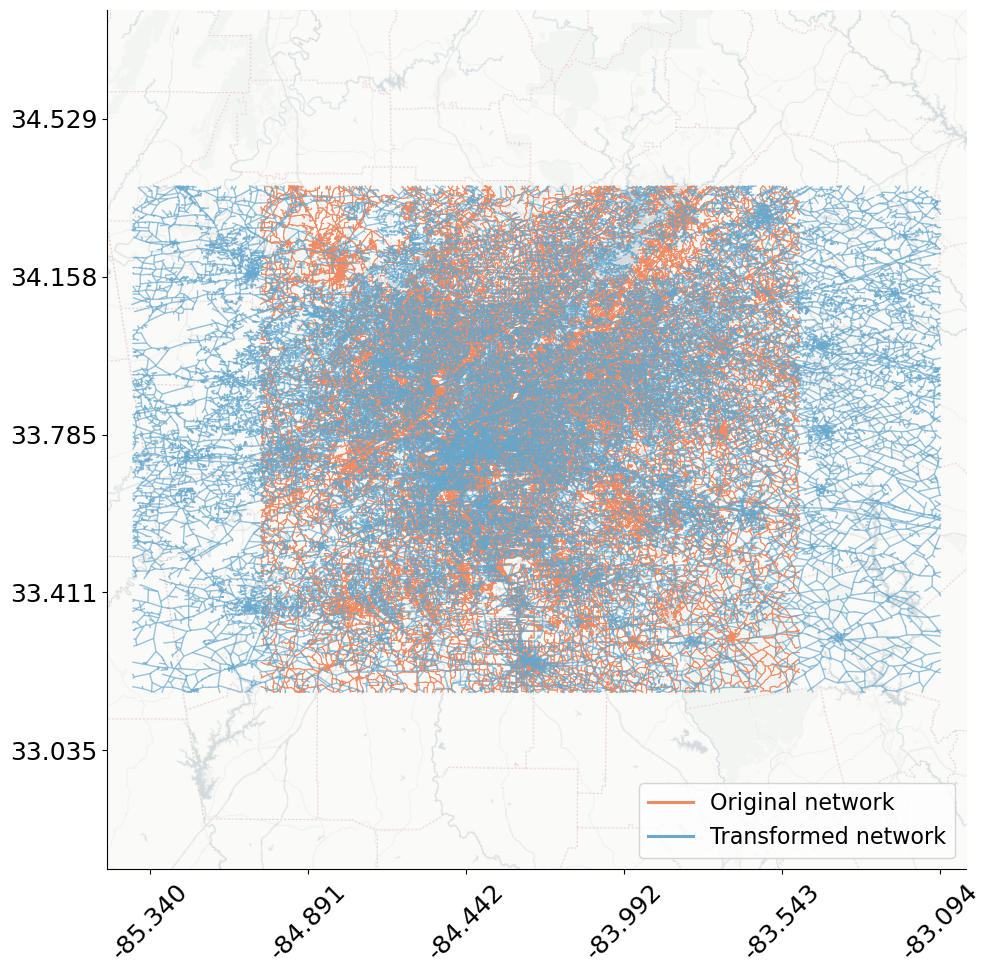

In [9]:
pad_frac = 0.03
basemap = "CartoDB.PositronNoLabels"
zoom = None  
trans_from_nodes = True
figsize = (10, 10)  # Dimensione fissa per entrambe le città
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 16

make_overlay_pdf(
    orig_pkl=orig_pkl,
    trans_pkl=trans_pkl,
    out_pdf=out_pdf,
    pad_frac=pad_frac,
    basemap=basemap,
    zoom=zoom,
    trans_from_nodes=trans_from_nodes,
    figsize=figsize
)